In [3]:
!pip install -e "/Users/lena/Desktop/Master/Nebenjob/biosonic"
!pip install praat-parselmouth

Obtaining file:///Users/lena/Desktop/Master/Nebenjob/biosonic
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for biosonic (pyproject.toml) ... done
  Created wheel for biosonic: filename=biosonic-0.0-0.editable-py3-none-any.whl size=3276 sha256=2a4158012d921f07e8e3917d10f13127866183ced959d40a60d47f5488dce770
  Stored in directory: /private/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/pip-ephem-wheel-cache-h5hz5u8a/wheels/3f/2a/22/c8a0279665cde42b2c4f3a99db539183436c1ac308a7ee23fa
Successfully built biosonic
  Attempting uninstall: biosonic
    Found existing installation: biosonic 0.0
    Uninstalling biosonic-0.0:
      Successfully uninstalled biosonic-0.0


In [4]:
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
import pandas as pd
import seaborn as sns
import random
import parselmouth
from skimage.transform import resize
from biosonic.handle import read_wav
from biosonic.compute.utils import extract_all_features
from biosonic.compute.spectrotemporal import spectrogram, cepstral_coefficients, tokuda_nlm
from biosonic.plot import plot_spectrogram

In [5]:
DATAPATH = "/Users/lena/Desktop/Master/Thesis/geese/data/noise_reduced/200highpass"
track_paths = glob.glob(DATAPATH+"/*.wav")
print(len(track_paths))

574


In [6]:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.RandomState(RANDOM_SEED)

RandomState(MT19937) at 0x13AE98B40

## Functions


In [7]:
spectrogram_cache = {}
signal_cache = {}

def compute_full_spectrogram(track_id, window_length=512, overlap=90):
    """Load audio and compute full spectrogram (cached by track_id)."""
    hop_length = int(window_length * (1 - overlap/100))  # hop = step size
    filename = os.path.join(DATAPATH, f"{track_id}_noise_reduced.wav")

    if not os.path.exists(filename):
        return None

    if track_id in spectrogram_cache:
        return spectrogram_cache[track_id]

    y, sr, _, _ = read_wav(filename)

    signal_cache[track_id] = (y, sr)

    S, t, f = spectrogram(y, sr, window_length=window_length, overlap=overlap)

    spectrogram_cache[track_id] = (S, t, f, sr, hop_length)

    return spectrogram_cache[track_id]

def _peak_normalize(data):
    # from biosound package: https://github.com/theunissenlab/BioSoundTutorial/blob/master/BioSound1.ipynb
    return np.array((data / np.max(np.abs(data))), np.float32)

def slice_signal(track_id, begin, end):
    """Return a signal snippet for a given time window."""
    if not track_id in spectrogram_cache:
        return None

    y, sr = signal_cache[track_id]
    if y is None:
        return None
    
    begin_idx = int(begin*sr)
    end_idx = int(end*sr)

    y_slice = y[begin_idx:end_idx]

    if len(y_slice) == 0 or np.max(y_slice) == 0:
        return None

    peak = np.max(y_slice)

    # Normalize to [0, 1]
    y_slice = _peak_normalize(y_slice)

    return y_slice, peak


def slice_spectrogram(track_id, begin, end):
    """Return a spectrogram snippet + axes for a given time window."""
    result = compute_full_spectrogram(track_id)
    if result is None:
        return None
    
    S, t, f, sr, hop_length = result

    # Slice time axis
    mask = (t >= begin) & (t <= end)
    S_slice = S[:, mask]
    t_slice = t[mask]

    if S_slice.shape[1] == 0 or np.max(S_slice) == 0:
        return None
    
    # Normalize to [0, 1]
    S_slice = S_slice / np.max(S_slice)

    return pd.Series([(S_slice, t_slice, f), sr, hop_length],
                     index=["clip_spectrogram", "sr", "hop_length"])


In [8]:
def _min_max_scale(data):
    # Normalizes to values between 0 and 1
    return (data - data.min()) / (data.max() - data.min())
    
def _to_pixel_and_cut(spectrogram):
    spectrogram = _min_max_scale(spectrogram)
    return spectrogram[:int(len(spectrogram)*0.4), :] # cut out higher frequencies where no power is left

In [9]:
# resize spectrogram to match the log scaled target size, reduce to a quarter of the size to avoid too much aliasing when resizing
def _resize_array(array, original_duration, target_duration, spectrogram):
    if spectrogram:
        array = _to_pixel_and_cut(array)
    else:
        array = _min_max_scale(array)
        
    if array is None or len(array) == 0:
        print("Empty or None array")
        return None
    
    if np.isnan(array).any():
        print("Array contains NaN values")
        return None

    bin_size_s = original_duration / len(array[1])
    target_bins_signal = int(target_duration / bin_size_s)

    try:
        # Resample array to match the target length
        if spectrogram: # reduce to a quarter of the size to avoid aliasing when rescaling to log time and for more effective processing past this point
            resized_array = resize(array, (array.shape[0] // 4, target_bins_signal // 4), anti_aliasing=False)
        else:
            resized_array = resize(array, (array.shape[0], target_bins_signal // 4), anti_aliasing=False) # not reducing coefficient resolution, but time resolution
        if np.isnan(resized_array).any():
            print("NaN in resampled array")
            return None
        
    except Exception as e:
        print(f"Error during resampling: {e}")
        return None
    
    return resized_array, target_bins_signal
    
# Resample and pad spectrograms, these are downsampled to a quarter of the resolution to avoid aliasing when rescaling to log time and for more effective processing past this point
def rescale_and_pad(array, original_duration, target_duration, target_bins_total, spectrogram=True):
    resized_array, target_bins_signal = _resize_array(array, original_duration, target_duration, spectrogram)

    # padding
    total_padding = target_bins_total // 4 - target_bins_signal // 4

    # if above 99th percentile - cut outer bins
    if total_padding < 0:
        return resized_array[:, :-np.abs(total_padding)] # cut bins on the right because reverb promotes trailing silence in clips

    left_padding = total_padding // 2
    right_padding = total_padding - left_padding
    padded_spectrogram = np.pad(resized_array, [(0, 0), (left_padding, right_padding)], "constant", constant_values=0)
    
    if np.isnan(padded_spectrogram).any():
        print("NaN in padded spectrogram")
        return None
    
    return padded_spectrogram


In [10]:
def trim_silence_waveform(y, sr, top_db=30, frame_length=2048, hop_length=512, margin=0.0):
    """
    Trim leading/trailing silence from an audio signal (librosa.effects.trim equivalent).
    """
    if not isinstance(y, np.ndarray) or y.size == 0:
        return np.array([]), (0, 0)
    
    # 1. Pad signal so last frame fits
    if len(y) < frame_length:
        y = np.pad(y, (0, frame_length - len(y)))

    # 2. Frame the signal (overlapping windows)
    frames = sliding_window_view(y, frame_length)[::int(hop_length)]

    # 3. Compute RMS per frame
    rms = np.sqrt(np.mean(frames**2, axis=1))

    # 4. Convert to dB
    rms_db = 20 * np.log10(rms + 1e-10)

    # 5. Threshold
    threshold = rms_db.max() - top_db
    non_silent = np.where(rms_db > threshold)[0]

    if len(non_silent) == 0:
        return np.array([]), (0, 0)

    # 6. Boundaries (use frame centers instead of starts)
    start_frame = non_silent[0]
    end_frame   = non_silent[-1]

    start_sample = start_frame * hop_length + frame_length // 2
    end_sample   = end_frame * hop_length + frame_length // 2

    # Clip to valid range
    start_sample = max(0, start_sample)
    end_sample   = min(len(y), end_sample)

    # 7. Apply margin (in samples)
    margin_samples = int(margin * sr)
    start_sample = int(max(0, start_sample - margin_samples))
    end_sample   = int(min(len(y), end_sample + margin_samples))

    return y[start_sample:end_sample], (start_sample, end_sample)

In [11]:
def apply_bounds_to_spectrogram(clip_spectrogram, bounds, hop_length):
    """
    Trim a spectrogram tuple (S, t, f) using precomputed waveform bounds.

    Parameters
    ----------
    clip_spectrogram : tuple
        (S, t, f)
    bounds : tuple
        (start_sample, end_sample) from trim_silence_waveform
    hop_length : int
        Hop length used in spectrogram
    sr : int
        Sample rate (used only for sanity check)

    Returns
    -------
    (S_trimmed, t_trimmed, f) : tuple
        Trimmed spectrogram and aligned axes
    """
    if clip_spectrogram is None or bounds is None:
        return None, (0, 0)

    S, t, f = clip_spectrogram
    start_sample, end_sample = bounds

    # Convert samples → frames
    start_frame = int(start_sample // hop_length)
    end_frame   = int(end_sample   // hop_length)

    # Safety check to avoid empty slice
    start_frame = max(0, min(start_frame, S.shape[1]-1))
    end_frame   = max(start_frame+1, min(end_frame, S.shape[1]))

    # Slice spectrogram and time axis
    S_trimmed = S[:, start_frame:end_frame]
    t_trimmed = t[start_frame:end_frame]

    return (S_trimmed, t_trimmed, f)


In [12]:
def trim_clip_spectrogram(clip_spectrogram, y, sr, hop_length, top_db=30, margin=0.0):
    """
    Trim a spectrogram tuple (S, t, f) based on silence trimming of waveform.

    Parameters
    ----------
    clip_spectrogram : tuple
        (S, t, f) where
        - S: spectrogram [freq_bins, time_frames]
        - t: time axis (seconds)
        - f: frequency axis (Hz)
    y : np.ndarray
        Corresponding waveform
    sr : int
        Sample rate
    hop_length : int
        Hop length used in spectrogram
    top_db : float
        Silence threshold in dB
    margin : float
        Extra margin (seconds) before/after non-silent region

    Returns
    -------
    (S_trimmed, t_trimmed, f) : tuple
        Trimmed spectrogram and aligned axes
    (start_frame, end_frame) : tuple
        Frame indices used for trimming
    """
    if clip_spectrogram is None or y is None or len(y) == 0:
        return None, (0, 0)

    S, t, f = clip_spectrogram

    # Trim waveform to get boundaries
    _, (start_sample, end_sample) = trim_silence_waveform(
        y, sr, top_db=top_db, frame_length=512, hop_length=hop_length, margin=margin
    )

    # Convert to frame indices
    start_frame = int(start_sample // hop_length)
    end_frame   = int(end_sample   // hop_length)


    # Slice spectrogram and time axis
    S_trimmed = S[:, start_frame:end_frame]
    t_trimmed = t[start_frame:end_frame]

    return (S_trimmed, t_trimmed, f), (start_frame, end_frame)


In [13]:
def trim_silence_spectrogram(S, threshold=None, axis=1, energy_percent=None, buffer=20, ref=1.0):
    """
    Trim a spectrogram by removing low-energy bins from the edges.

    Parameters
    ----------
    S : np.ndarray
        Spectrogram (shape: [freq_bins, time_frames])
    threshold : float, optional
        Minimum energy required to keep a bin. If None, uses energy_percent.
    axis : int, optional
        Axis along which to trim:
        - 1 (default): trims time frames (columns)
        - 0: trims frequency bins (rows)
    energy_percent : float, optional
        If set (0 < energy_percent <= 1), trims to keep only the bins that
        contain this fraction of the total energy (e.g. 0.95 for 95%).

    Returns
    -------
    S_trimmed : np.ndarray
        Trimmed spectrogram
    first : int
        Index of the first kept bin
    last : int
        Index of the last kept bin
    """
    # Energy per bin (sum across the opposite axis)
    bin_energy = np.sum(np.abs(S)**2, axis=1-axis)
    if energy_percent is not None:
        total_energy = np.sum(bin_energy)
        cumulative = np.cumsum(bin_energy)
        first = np.argmax(cumulative >= (1 - energy_percent) * total_energy)
        last = len(bin_energy) - np.argmax(cumulative[::-1] <= energy_percent * total_energy) -1
    else:
        if threshold is None:
            raise ValueError("Either `threshold` or `energy_percent` must be provided.")
        valid = bin_energy > threshold
        if not np.any(valid):
            return np.empty((0, 0)), None, None
        first = np.argmax(valid)
        last = len(valid) - np.argmax(valid[::-1]) -1

    # Add buffer and clip
    first = max(first - buffer, 0)
    last = min(last + buffer, S.shape[axis]-1)

    if axis == 1:  # trim columns (time)
        S_trimmed = S[:, first:last+1]
    else:  # trim rows (frequency)
        S_trimmed = S[first:last+1, :]

    return S_trimmed, (first, last, axis)


In [14]:
def add_spectrogram_borders(ax, t, f, borders, 
                            border_colors=("lime", "red"), 
                            linewidth=1.5, linestyle="--"):
    """
    Add trim borders to an existing spectrogram plot.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The axes with a spectrogram already plotted.
    t : np.ndarray
        Time vector used in the spectrogram plot.
    f : np.ndarray
        Frequency vector used in the spectrogram plot.
    borders : tuple(int, int, int)
        (first, last, axis) indices from trimming.
        - axis=1: vertical (time) borders
        - axis=0: horizontal (frequency) borders
    border_colors : tuple(str, str)
        Colors for (first, last) borders.
    linewidth : float
        Width of the border lines.
    linestyle : str
        Style of the border lines.
    """
    if borders is None:
        return

    first, last, axis = borders
    c1, c2 = border_colors

    if axis == 1:  # time axis
        ax.axvline(t[first], color=c1, linestyle=linestyle, lw=linewidth)
        ax.axvline(t[last], color=c2, linestyle=linestyle, lw=linewidth)
    else:  # frequency axis
        ax.axhline(f[first], color=c1, linestyle=linestyle, lw=linewidth)
        ax.axhline(f[last], color=c2, linestyle=linestyle, lw=linewidth)

In [15]:
def plot_spectrogram_with_borders(S, t, f, sr, borders, plot, cmap="binary", dynamic_range=70, title=""):
    fig, ax=plot
    plot_spectrogram((S, t, f), sr, flim=(150, 17500), cmap=cmap, dynamic_range=dynamic_range, plot=plot, title=title)

    # Add borders on top
    add_spectrogram_borders(ax, t, f, borders)

In [16]:
def plot_waveform_with_borders(y, sr, borders, ax, border_colors=("lime", "red"), linewidth=1.5, linestyle="--"):
    """
    Plot waveform with trim borders.

    Parameters
    ----------
    y : np.ndarray
        Waveform
    sr : int
        Sample rate
    borders : tuple(int, int, int)
        (first_sample, last_sample, axis=1)
    ax : matplotlib.axes.Axes
        Axis to plot waveform on
    """
    t = np.arange(len(y)) / sr
    ax.plot(t, y, color="black", linewidth=0.8)
    ax.set_xlim([t[0], t[-1]])
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")

    if borders is not None:
        first, last, axis = borders
        c1, c2 = border_colors
        ax.axvline(first / sr, color=c1, linestyle=linestyle, lw=linewidth)
        ax.axvline(last / sr,  color=c2, linestyle=linestyle, lw=linewidth)


In [17]:
def batch_plot_all_spectrograms(
        df, 
        column="clip_spectrogram", 
        per_page=20,     # fewer per page since we now plot 2x rows
        ncols=2,
        save_dir=None,
        show=True,
        prefix="spectrograms",
        with_borders=True
):
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    n = len(df)
    n_pages = int(np.ceil(n / per_page))

    for page in range(n_pages):
        start = page * per_page
        end = min((page + 1) * per_page, n)
        subset = df.iloc[start:end]

        nrows = 2 * int(np.ceil(len(subset) / ncols))  # 2 rows per item
        fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 2*nrows))
        axes = np.atleast_1d(axes).reshape(nrows, ncols)

        for idx, (_, row) in enumerate(subset.iterrows()):
            r, c = divmod(idx, ncols)
            ax_spec = axes[2*r, c]     # spectrogram row
            ax_wave = axes[2*r+1, c]   # waveform row

            snippet = row[column]
            if snippet is None:
                ax_spec.axis("off")
                ax_wave.axis("off")
                continue

            S, t, f = snippet
            hop_length = int(row["hop_length"])
            sr = row["sr"]

            if with_borders:
                # Get trim borders
                y = row["clip_signal"]
                _, (s, e) = trim_silence_waveform(y, sr, top_db=35, frame_length=512, hop_length=hop_length, margin=0.005)
                borders_spec = (
                    max(0, min(s // hop_length, S.shape[1]-1)),
                    max(0, min(e // hop_length, S.shape[1]-1)),
                    1
                )
                borders_wave = (s, e, 1)

                plot_spectrogram_with_borders(
                    S, t, f, sr, borders_spec,
                    (fig, ax_spec),
                    cmap="binary",
                    dynamic_range=70,
                    title=f"{row['Clip ID']}|{row['Call Type']}|{row['peak']}",
                )
                plot_waveform_with_borders(y, sr, borders_wave, ax_wave)

            else:
                plot_spectrogram(
                    (S, t, f),
                    sr,
                    db_scale=True,
                    title=f"{row['Clip ID']}|{row['Call Type']}|{row['peak']}",
                    plot=(fig, ax_spec), 
                    cmap="binary",
                    dynamic_range=70,
                    flim=(150, 17500)
                )
                ax_wave.plot(np.arange(len(row["clip_signal"])) / sr, row["clip_signal"], color="black", linewidth=0.8)
                ax_wave.set_xlabel("Time (s)")
                ax_wave.set_ylabel("Amplitude")

        plt.tight_layout()

        if save_dir is not None:
            filename = os.path.join(save_dir, f"{prefix}_{page+1:03d}.png")
            fig.savefig(filename, dpi=150)
            print(f"Saved {filename}")

        if show:
            plt.show()
        else:
            plt.close(fig)

## Analysis
### Read in selections df and prepare spectrograms

In [18]:
selections_df = pd.read_csv("/Users/lena/Desktop/Master/Thesis/geese/code/GooseVocalizations/selections_tracks.csv")
selections_df.head()

,Unnamed: 0,Track ID,Clip ID,Bout Call ID * formerly Neckband Nr; but no single entry was made,Goose ID,upper left,mid left,lower left,upper right,mid right,...,Comment,Wav Treatment,Context,Recorder ID,...24,Begin Time (s),End Time (s),Call Type,unsure,same_track
0,0,GT00002,G00024,NaN,Burglar,silver,NaN,NaN,green,Alu,...,before flying away,NaN,NaN,Marie,NaN,0.388821,0.606506,departure,0,False
1,1,GT00002,G00025,NaN,Burglar,silver,NaN,NaN,green,Alu,...,before flying away,NaN,NaN,Marie,NaN,3.129735,3.346051,departure,0,True
2,2,GT00002,G00026,NaN,Burglar,silver,NaN,NaN,green,Alu,...,before flying away,NaN,NaN,Marie,NaN,4.056370,4.253519,departure,0,True
3,3,GT00002,G00027,NaN,Burglar,silver,NaN,NaN,green,Alu,...,before flying away,NaN,NaN,Marie,NaN,4.960205,5.157354,departure,0,True
4,4,GT00002,G00028,NaN,Burglar,silver,NaN,NaN,green,Alu,...,before flying away,NaN,NaN,Marie,NaN,5.919936,6.110239,departure,0,True


In [19]:
selections_df[["clip_spectrogram", "sr", "hop_length"]] = selections_df.apply(
    lambda row: slice_spectrogram(row["Track ID"], row["Begin Time (s)"], row["End Time (s)"]),
    axis=1
)

In [20]:
selections_df[["clip_signal", "peak"]] = selections_df.apply(
    lambda row: slice_signal(row["Track ID"], row["Begin Time (s)"], row["End Time (s)"]),
    axis=1
).apply(pd.Series)

In [21]:
selections_df.head()

,Unnamed: 0,Track ID,Clip ID,Bout Call ID * formerly Neckband Nr; but no single entry was made,Goose ID,upper left,mid left,lower left,upper right,mid right,...,Begin Time (s),End Time (s),Call Type,unsure,same_track,clip_spectrogram,sr,hop_length,clip_signal,peak
0,0,GT00002,G00024,NaN,Burglar,silver,NaN,NaN,green,Alu,...,0.388821,0.606506,departure,0,False,"([[4.5962524e-06, 1.6756521e-06, 2.3678585e-07...",44100.0,51.0,"[0.0013553196, 0.0015812062, 0.0013553196, 0.0...",0.135105
1,1,GT00002,G00025,NaN,Burglar,silver,NaN,NaN,green,Alu,...,3.129735,3.346051,departure,0,True,"([[1.3958083e-05, 1.8058685e-05, 1.9480482e-05...",44100.0,51.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.405042
2,2,GT00002,G00026,NaN,Burglar,silver,NaN,NaN,green,Alu,...,4.056370,4.253519,departure,0,True,"([[1.0939993e-05, 1.02520125e-05, 3.0683816e-0...",44100.0,51.0,"[-0.003295425, -0.003230809, -0.0031661927, -0...",0.455031
3,3,GT00002,G00027,NaN,Burglar,silver,NaN,NaN,green,Alu,...,4.960205,5.157354,departure,0,True,"([[8.430568e-06, 9.72437e-06, 1.2311477e-05, 2...",44100.0,51.0,"[-6.710959e-05, -6.710959e-05, 0.0, 0.0, 6.710...",0.435316
4,4,GT00002,G00028,NaN,Burglar,silver,NaN,NaN,green,Alu,...,5.919936,6.110239,departure,0,True,"([[1.2291771e-05, 2.5481586e-06, 1.8561854e-05...",44100.0,51.0,"[0.00013823611, 0.00020735417, 0.00013823611, ...",0.417035


In [22]:
selections_df.to_pickle("clips_df.pkl")

In [23]:
selections_df["peak_bin"] = pd.cut(
    selections_df["peak"],
    bins=[0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 1],
    labels=["0–0.05", "0.05-0.1", "0.1-0.2", "0.2-0.3", "0.3-0.4", "0.4-0.5", "0.5-0.7","0.7-1"]
)

[]

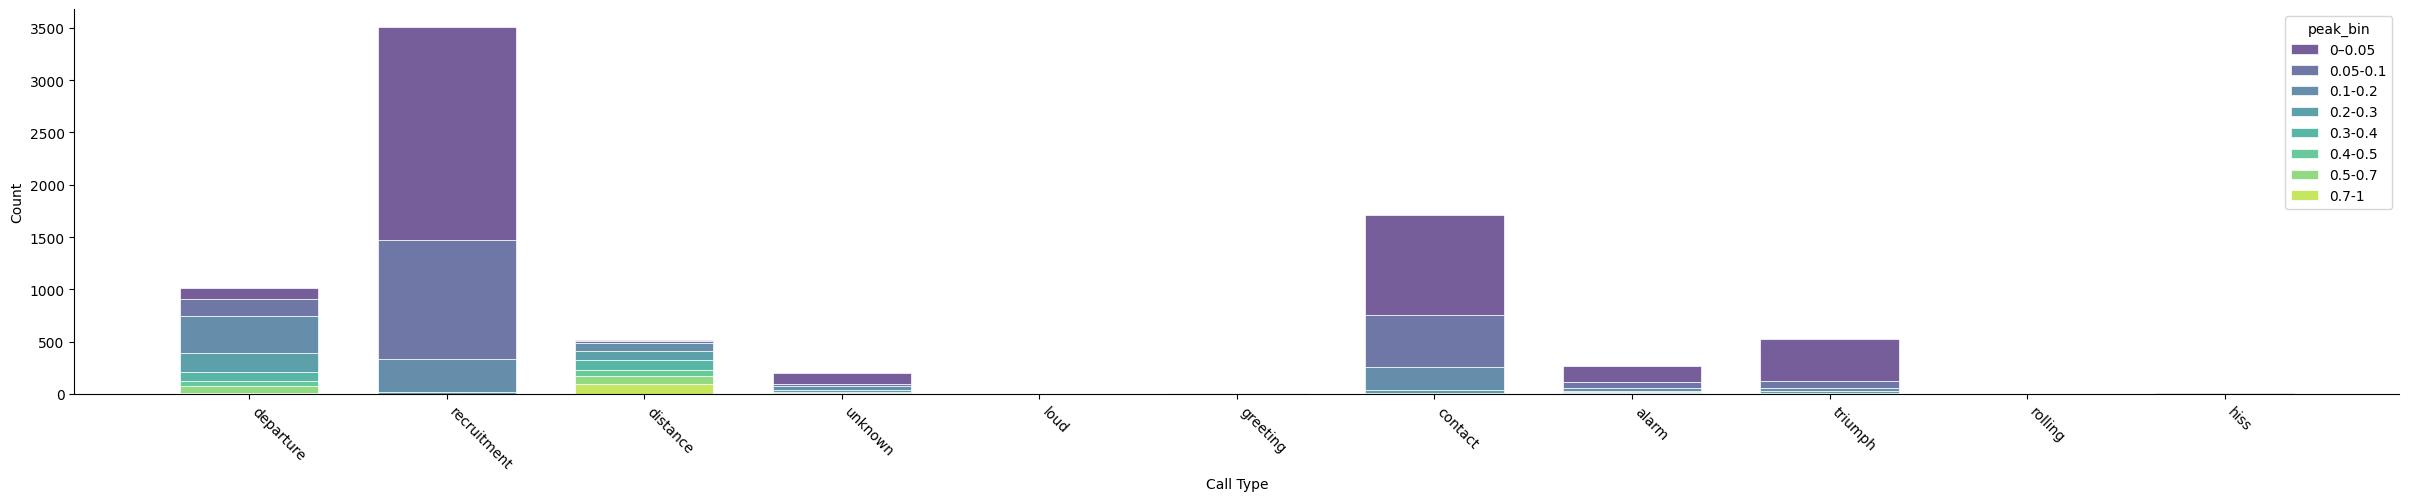

In [24]:
f, ax = plt.subplots(figsize=(30, 5))
sns.despine(f)

sns.histplot(
    selections_df,
    x="Call Type",
    multiple="stack",
    hue="peak_bin",
    palette="viridis",
    edgecolor="1",
    linewidth=.5,
    shrink=.7
)
plt.xticks(rotation=-45, ha='left')
plt.plot()

In [25]:
# discard loud, greeting and rolling calls
filtered_df = selections_df[~selections_df['Call Type'].isin(['loud', 'greeting', 'rolling'])]

In [26]:
# filter out clipped and low amplitude clips
with open("noisy_clips.txt", "r") as f:
    noisy_clips = {line.strip() for line in f if line.strip()}

filtered_df = filtered_df[
    (selections_df["peak"] >= 0.013) & 
    (selections_df["peak"] <= 0.975) &
    (~selections_df["Clip ID"].isin(noisy_clips))
    ].sort_values(by=["Clip ID"])

/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_86214/2761355325.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_df = filtered_df[


[]

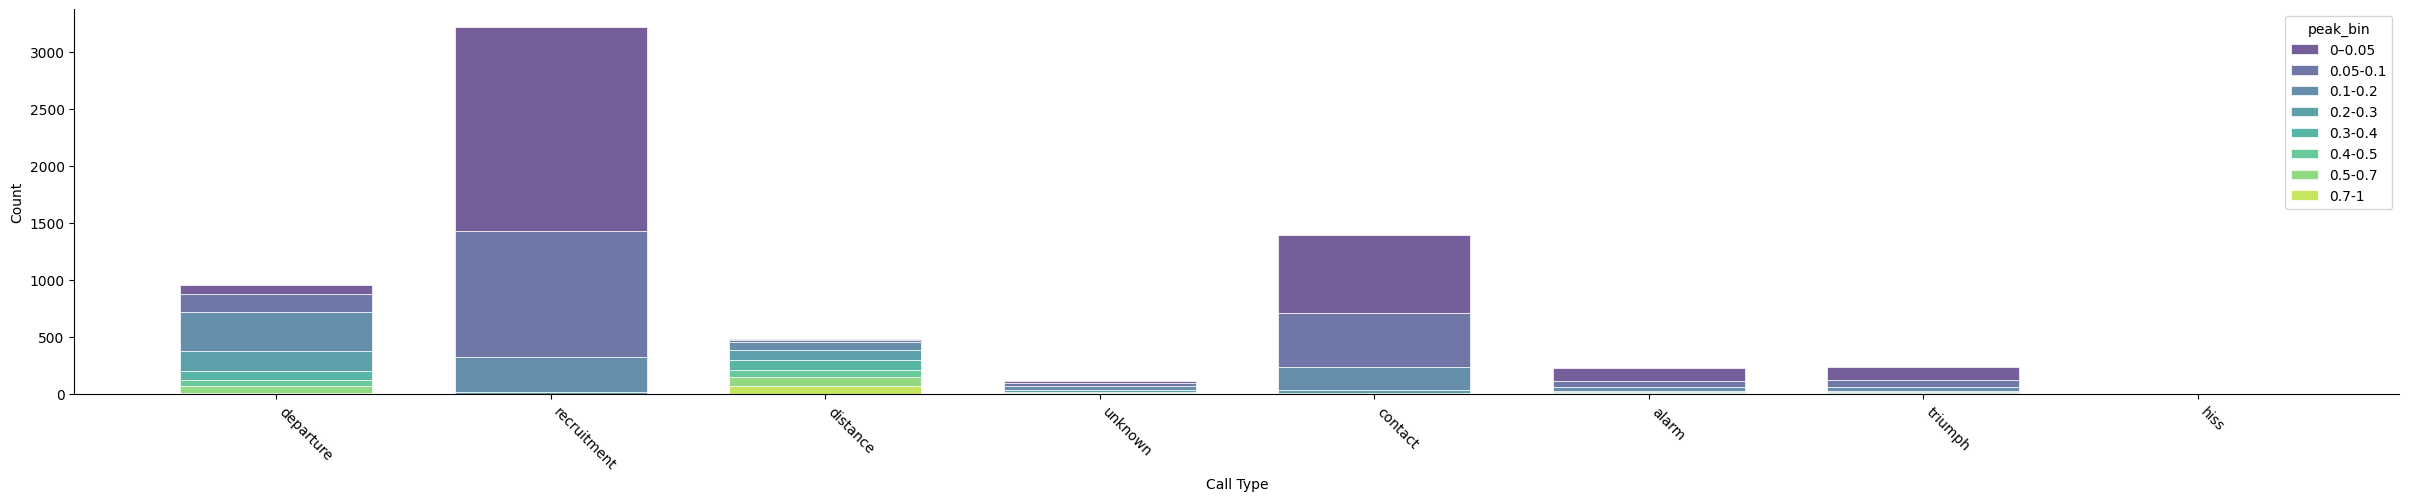

In [27]:
f, ax = plt.subplots(figsize=(30, 5))
sns.despine(f)

sns.histplot(
    filtered_df,
    x="Call Type",
    multiple="stack",
    hue="peak_bin",
    palette="viridis",
    edgecolor="1",
    linewidth=.5,
    shrink=.7,
)
plt.xticks(rotation=-45, ha='left')
plt.plot()

In [28]:
# batch_plot_all_spectrograms(filtered_df, per_page=25, ncols=5, show=True, save_dir="spectrograms")

In [29]:
filtered_df[["clip_signal_trimmed", "clip_signal_bounds"]] = filtered_df.apply(
    lambda row: pd.Series(
        trim_silence_waveform(
            row["clip_signal"],
            row["sr"],
            top_db=35,
            frame_length=512,
            margin=0.01
        ),
        index=["clip_signal_trimmed", "clip_signal_bounds"]
    ),
    axis=1
)

In [30]:
filtered_df["clip_spectrogram_trimmed"] = filtered_df.apply(
    lambda row: 
        apply_bounds_to_spectrogram(
            row["clip_spectrogram"],
            row["clip_signal_bounds"],
            row["hop_length"]
        ),
    axis=1
)

In [31]:
columns_to_drop = [
    "Bout Call ID * formerly Neckband Nr; but no single entry was made",
    "upper left",
    "mid left",
    "lower left",
    "upper right",
    "mid right",
    "lower right",
    "clip_spectrogram",
    "hop_length",
    "clip_signal",
    "peak",
    "peak_bin",
    "Unnamed: 0",
    "...24",
    "Wav Treatment"
    ]
filtered_df = filtered_df.drop(columns=columns_to_drop)

In [32]:
filtered_df.head()

,Track ID,Clip ID,Goose ID,Location,Day,Month,Year,Date,Time,Recorder,...,Recorder ID,Begin Time (s),End Time (s),Call Type,unsure,same_track,sr,clip_signal_trimmed,clip_signal_bounds,clip_spectrogram_trimmed
0,GT00002,G00024,Burglar,KLF grass,4.0,9.0,2020.0,04.Sep.2020,9.30am,NaN,...,Marie,0.388821,0.606506,departure,0,False,44100.0,"[0.0013553196, 0.0015812062, 0.0013553196, 0.0...","(0, 8377)","([[4.5962524e-06, 1.6756521e-06, 2.3678585e-07..."
1,GT00002,G00025,Burglar,KLF grass,4.0,9.0,2020.0,04.Sep.2020,9.30am,NaN,...,Marie,3.129735,3.346051,departure,0,True,44100.0,"[0.0009446988, 0.0013807137, 0.0013080444, 0.0...","(839, 8377)","([[3.057722e-05, 2.2692295e-05, 2.164964e-05, ..."
2,GT00002,G00026,Burglar,KLF grass,4.0,9.0,2020.0,04.Sep.2020,9.30am,NaN,...,Marie,4.056370,4.253519,departure,0,True,44100.0,"[0.0030369605, 0.0027784957, 0.0023261823, 0.0...","(327, 7865)","([[1.7977347e-05, 1.2150071e-05, 1.3325338e-05..."
3,GT00002,G00027,Burglar,KLF grass,4.0,9.0,2020.0,04.Sep.2020,9.30am,NaN,...,Marie,4.960205,5.157354,departure,0,True,44100.0,"[0.0006039863, 0.0006039863, 0.0004697671, 0.0...","(327, 6841)","([[1.2614673e-05, 1.733473e-05, 1.1986869e-05,..."
4,GT00002,G00028,Burglar,KLF grass,4.0,9.0,2020.0,04.Sep.2020,9.30am,NaN,...,Marie,5.919936,6.110239,departure,0,True,44100.0,"[-0.00048382638, -0.00048382638, -0.0003455902...","(327, 7353)","([[3.0433774e-05, 1.845236e-05, 4.1414045e-05,..."


In [33]:
# batch_plot_all_spectrograms(filtered_df, column="clip_spectrogram_trimmed", per_page=25, ncols=5, show=True, with_borders=False)

In [34]:
# segment distance calls

In [35]:
# lfccs and mfccs
filtered_df["lfccs"] = filtered_df.apply(
    lambda row: 
        cepstral_coefficients(
            row["clip_signal_trimmed"],
            row["sr"],
            filterbank_type="linear"
        ),
    axis=1
)
filtered_df["mfccs"] = filtered_df.apply(
    lambda row: 
        cepstral_coefficients(
            row["clip_signal_trimmed"],
            row["sr"],
        ),
    axis=1
)

In [36]:
# extract features
feature_rows = []

for i, row in filtered_df.iterrows():
    try:
        features = extract_all_features(row["clip_signal_trimmed"], row["sr"])
        features["Clip ID"] = row["Clip ID"]
        feature_rows.append(features)
    except Exception as e:
        print(f"Failed to process {row["Clip ID"]}: {e}")

out_df = pd.DataFrame(feature_rows)

In [37]:
merged_df = pd.merge(
    filtered_df,
    out_df,
    on="Clip ID",
    how="left"
)

In [38]:
merged_df.head()

,Track ID,Clip ID,Goose ID,Location,Day,Month,Year,Date,Time,Recorder,...,spectral_kurtosis,peak_frequency,pse,spectrotemporal_entropy,dominant_freqs,mean_dom,min_dom,max_dom,range_dom,mod_dom
0,GT00002,G00024,Burglar,KLF grass,4.0,9.0,2020.0,04.Sep.2020,9.30am,NaN,...,8.295626,4132.565358,0.618024,0.565815,"[2239.453125, 2153.3203125, 2153.3203125, 2325...",2881.281502,1894.921875,4134.375000,2239.453125,2.076923
1,GT00002,G00025,Burglar,KLF grass,4.0,9.0,2020.0,04.Sep.2020,9.30am,NaN,...,5.833470,1152.520562,0.558154,0.475579,"[2153.3203125, 2067.1875, 1119.7265625, 1033.5...",1144.335938,689.062500,2153.320312,1464.257812,1.588235
2,GT00002,G00026,Burglar,KLF grass,4.0,9.0,2020.0,04.Sep.2020,9.30am,NaN,...,5.933242,1158.370921,0.592946,0.496790,"[602.9296875, 2239.453125, 2067.1875, 3875.976...",1408.886719,602.929688,3875.976562,3273.046875,4.026316
3,GT00002,G00027,Burglar,KLF grass,4.0,9.0,2020.0,04.Sep.2020,9.30am,NaN,...,5.991745,1150.905741,0.568506,0.478167,"[2067.1875, 3875.9765625, 3962.109375, 1033.59...",1464.257812,947.460938,3962.109375,3014.648438,2.200000
4,GT00002,G00028,Burglar,KLF grass,4.0,9.0,2020.0,04.Sep.2020,9.30am,NaN,...,5.870500,1129.803587,0.581715,0.499596,"[2239.453125, 1119.7265625, 1119.7265625, 1119...",1136.290565,689.062500,2239.453125,1550.390625,1.444444


In [39]:
# log pad
merged_df['log_duration'] = merged_df.apply(lambda row: np.log(row['duration']), axis=1)

In [40]:
longest_call_total = merged_df.loc[merged_df["duration"].idxmax()]
# take the longest call of 99.7th percentile for max length
filtered_by_percentile = merged_df.loc[merged_df["duration"] >= np.quantile(merged_df["duration"], 0.9992)]
# take the shortest call among those long calls
longest_call_quantile = filtered_by_percentile.loc[filtered_by_percentile["duration"].idxmin()]
max_bins_spectro = len(longest_call_quantile["clip_spectrogram_trimmed"][1])
max_bins_lfcc = longest_call_quantile["lfccs"].shape[1]
max_bins_mfcc = longest_call_quantile["mfccs"].shape[1]

max_log_duration = longest_call_quantile["log_duration"]
max_duration_seconds = longest_call_quantile["duration"]
shortest_call = merged_df.loc[merged_df["duration"].idxmin()]

min_log_duration = shortest_call["log_duration"]
min_duration_seconds = shortest_call["duration"]

# Compute log scaled target length for the waveform
merged_df["normalized_log_length"] = merged_df.apply(lambda row: (row["log_duration"]-min_log_duration)/(max_log_duration-min_log_duration), axis=1)
merged_df["log_target_duration"] = merged_df.apply(lambda row: row["normalized_log_length"]*(max_duration_seconds-min_duration_seconds)+min_duration_seconds, axis=1)

# sanity check
print(merged_df.loc[merged_df["duration"].idxmin()]["log_target_duration"], min_duration_seconds)
print(merged_df.loc[merged_df["duration"].idxmax()]["log_target_duration"], max_duration_seconds)

0.038639455782312926 0.038639455782312926
0.9930232840206956 0.947891156462585


In [41]:
# Apply transformation to each spectrogram
merged_df["log_padded_spectrogram"] = merged_df.apply(
    lambda row: rescale_and_pad(
        row["clip_spectrogram_trimmed"][0],
        row["duration"],
        row["log_target_duration"],
        max_bins_spectro
    ),
    axis=1
)

# Apply transformation to lfccs
merged_df["log_padded_lfccs"] = merged_df.apply(
    lambda row: rescale_and_pad(
        row["lfccs"],
        row["duration"],
        row["log_target_duration"],
        max_bins_lfcc,
        spectrogram=False
    ),
    axis=1
)

# Apply transformation to mfccs
merged_df["log_padded_mfccs"] = merged_df.apply(
    lambda row: rescale_and_pad(
        row["mfccs"],
        row["duration"],
        row["log_target_duration"],
        max_bins_mfcc,
        spectrogram=False
    ),
    axis=1
)

In [42]:
print(np.max(np.concatenate(merged_df["log_padded_lfccs"].apply(lambda x: x.ravel()).values)),
      np.min(np.concatenate(merged_df["log_padded_lfccs"].apply(lambda x: x.ravel()).values)))

print(np.max(np.concatenate(merged_df["log_padded_mfccs"].apply(lambda x: x.ravel()).values)),
      np.min(np.concatenate(merged_df["log_padded_mfccs"].apply(lambda x: x.ravel()).values)))

print(np.max(np.concatenate(merged_df["log_padded_spectrogram"].apply(lambda x: x.ravel()).values)),
      np.min(np.concatenate(merged_df["log_padded_spectrogram"].apply(lambda x: x.ravel()).values)))

1.0 0.0
1.0 0.0
0.9984101 0.0


[]

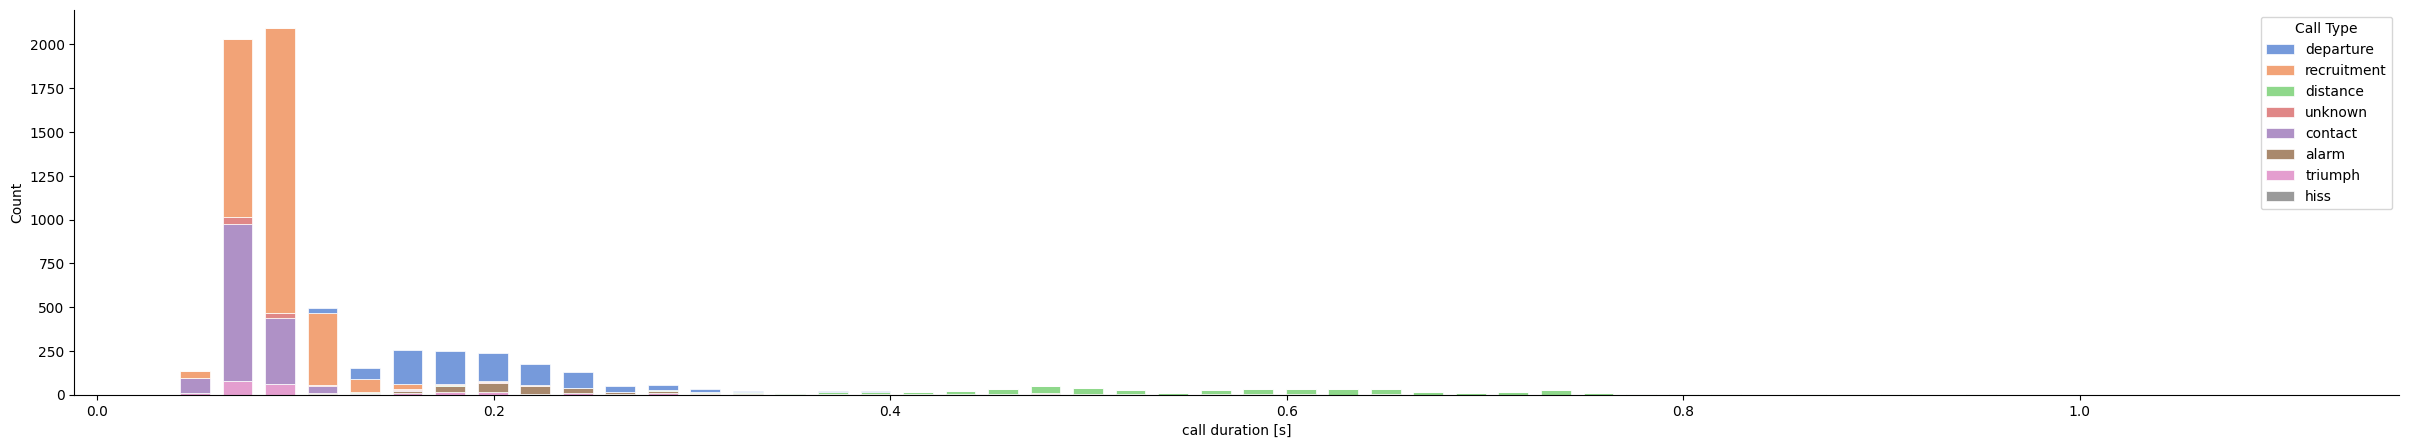

In [43]:
f, ax = plt.subplots(figsize=(30, 5))
sns.despine(f)

sns.histplot(
    merged_df,
    x="duration",
    multiple="stack",
    hue="Call Type",
    palette="muted",
    edgecolor="1",
    linewidth=.5,
    shrink=.7,
    bins=50,
)
ax.set_xlabel("call duration [s]")
plt.plot()

[]

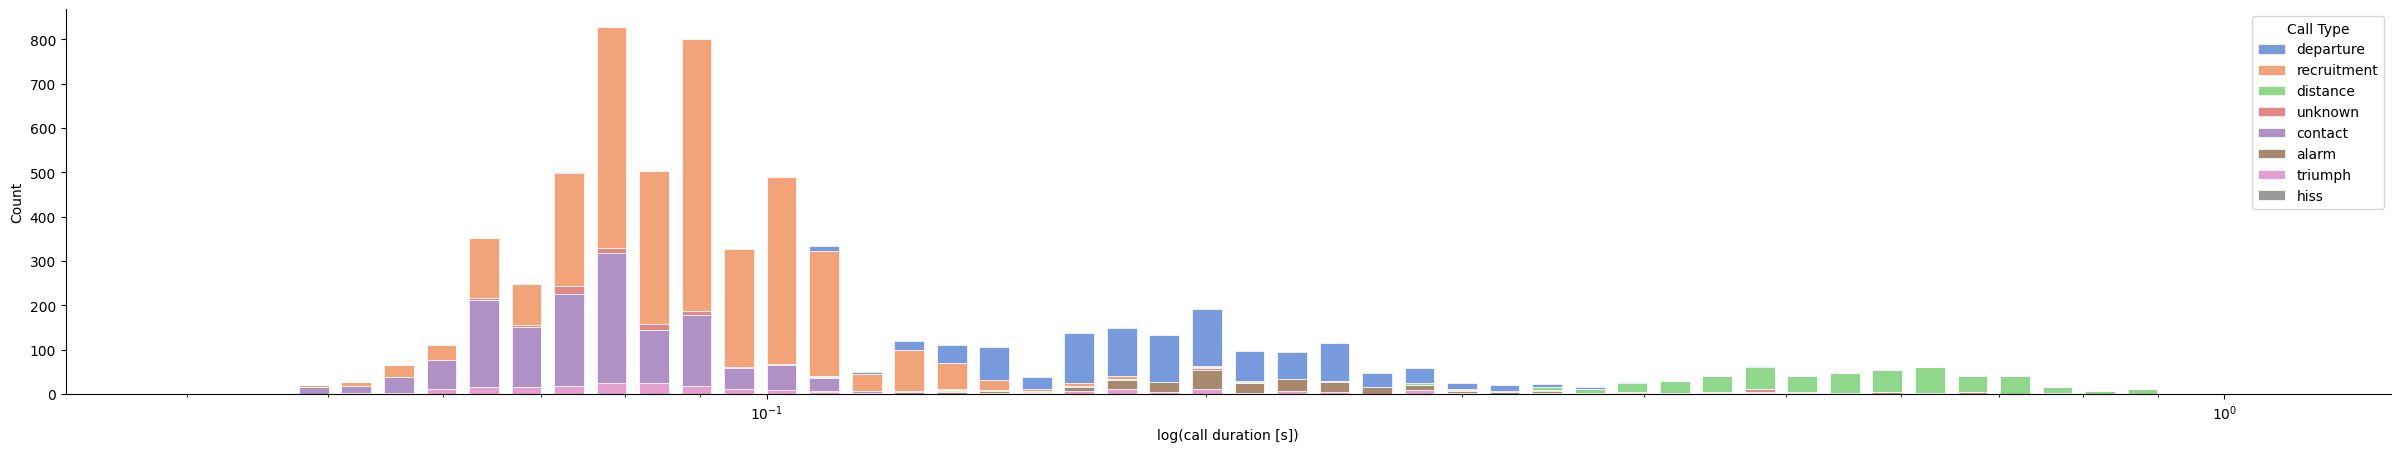

In [44]:
f, ax = plt.subplots(figsize=(30, 5))
sns.despine(f)

sns.histplot(
    merged_df,
    x="duration",
    multiple="stack",
    hue="Call Type",
    palette="muted",
    edgecolor="1",
    linewidth=.5,
    shrink=.7,
    bins=50,
    log_scale=True
)
ax.set_xlabel("log(call duration [s])")
plt.plot()

[]

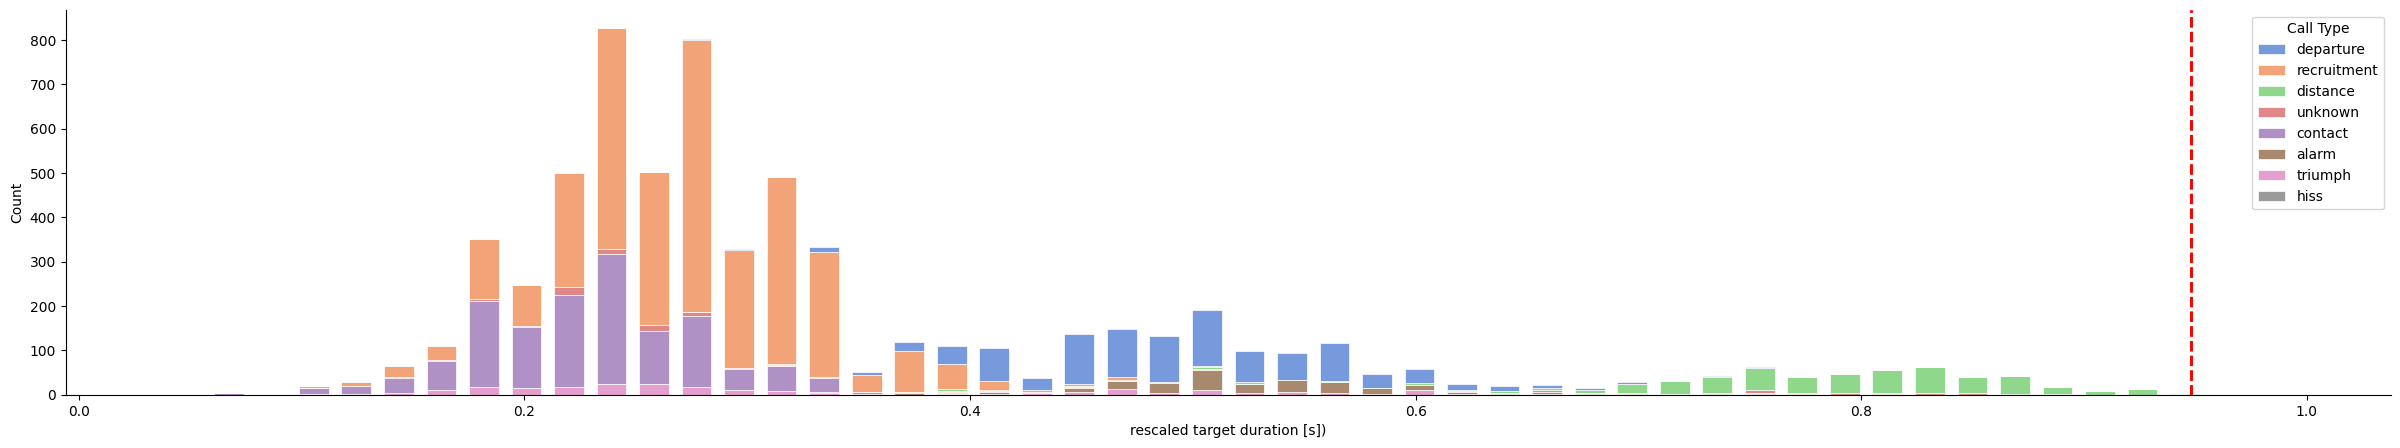

In [45]:
f, ax = plt.subplots(figsize=(30, 5))
sns.despine(f)

histplot = sns.histplot(
    merged_df,
    x="log_target_duration",
    multiple="stack",
    hue="Call Type",
    palette="muted",
    edgecolor="1",
    linewidth=.5,
    shrink=.7,
    bins=50,
    ax=ax
)
ax.set_xlabel("rescaled target duration [s])")


quantile = np.quantile(merged_df["duration"], 0.9992)
filtered_by_percentile = merged_df.loc[merged_df["duration"] >= quantile]
longest_call_quantile = filtered_by_percentile.loc[filtered_by_percentile["duration"].idxmin()]

ax.axvline(longest_call_quantile["duration"], color='red', linestyle='--', linewidth=2, label=f'99th Percentile: {longest_call_quantile["duration"]:.2f}')

ax.axvline(longest_call_quantile["duration"], color='red', linestyle='--', linewidth=2, label=f'99th Percentile: {longest_call_quantile["log_target_duration"]:.2f}')


plt.plot()

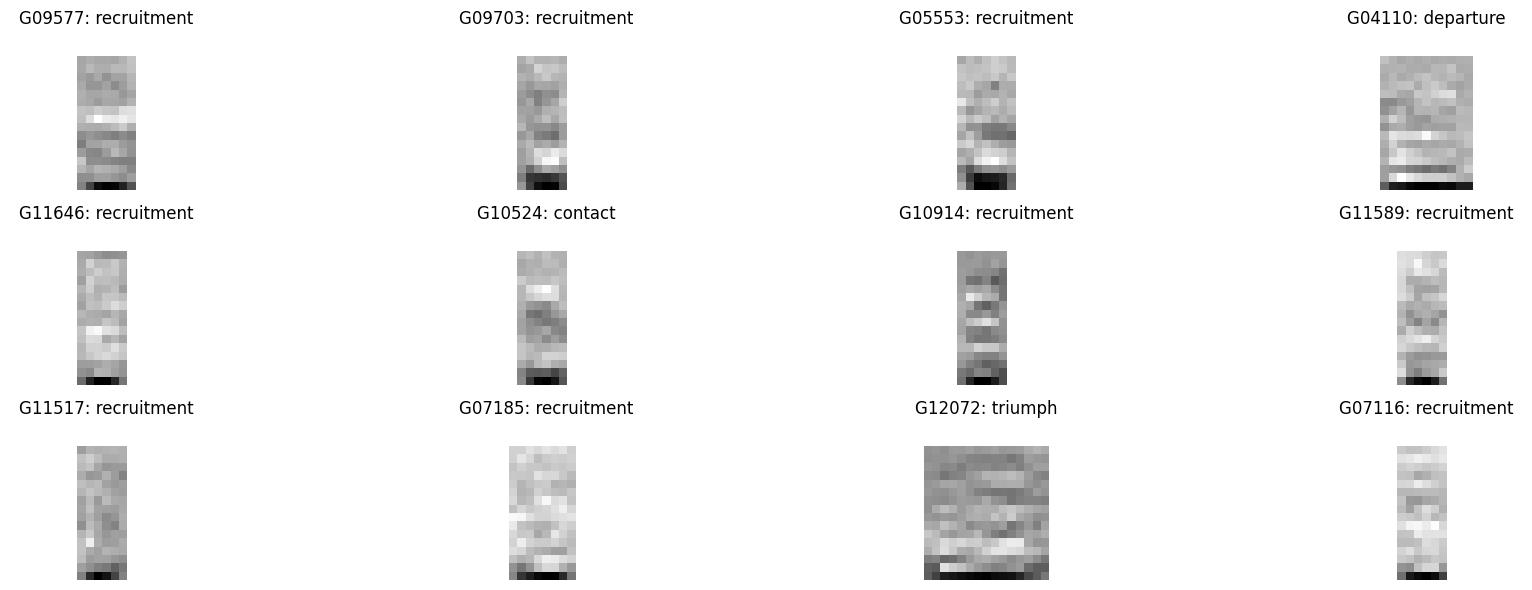

In [46]:
# plot random sample of 8 calls, linearly scaled and padded
sample_calls = merged_df.sample(n=12, random_state=2300)

fig, axes = plt.subplots(3, 4, figsize=(19, 6))

for i, (_, vocalization) in enumerate(sample_calls.iterrows()):
  row = i // 4
  col = i % 4
  axes[row, col].matshow(vocalization["log_padded_lfccs"], origin="lower", cmap="binary")
  axes[row, col].set_title(f'{vocalization["Clip ID"]}: {vocalization["Call Type"]}', )
  axes[row, col].axis("off") 
    
for i in range(len(sample_calls), 8):
  row = i // 4
  col = i % 4
  axes[row, col].axis("off")

plt.tight_layout()
plt.show()

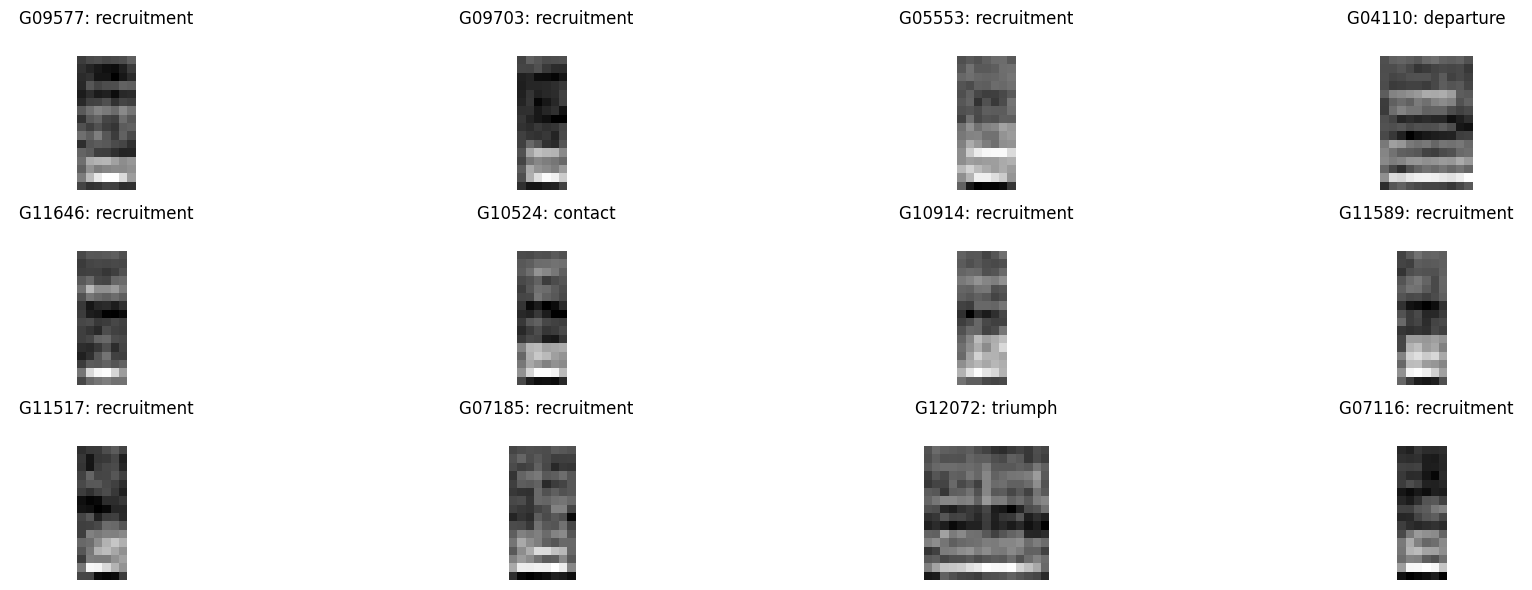

In [47]:
# plot random sample of 8 calls, linearly scaled and padded
sample_calls = merged_df.sample(n=12, random_state=2300)

# plot first 8 calls
#sample_calls = calls_df.iloc[:8]

fig, axes = plt.subplots(3, 4, figsize=(19, 6))

for i, (_, vocalization) in enumerate(sample_calls.iterrows()):
  row = i // 4
  col = i % 4
  axes[row, col].matshow(vocalization["log_padded_mfccs"], origin="lower", cmap="binary")
  axes[row, col].set_title(f'{vocalization["Clip ID"]}: {vocalization["Call Type"]}', )
  axes[row, col].axis("off") 
    
for i in range(len(sample_calls), 8):
  row = i // 4
  col = i % 4
  axes[row, col].axis("off")

plt.tight_layout()
plt.show()

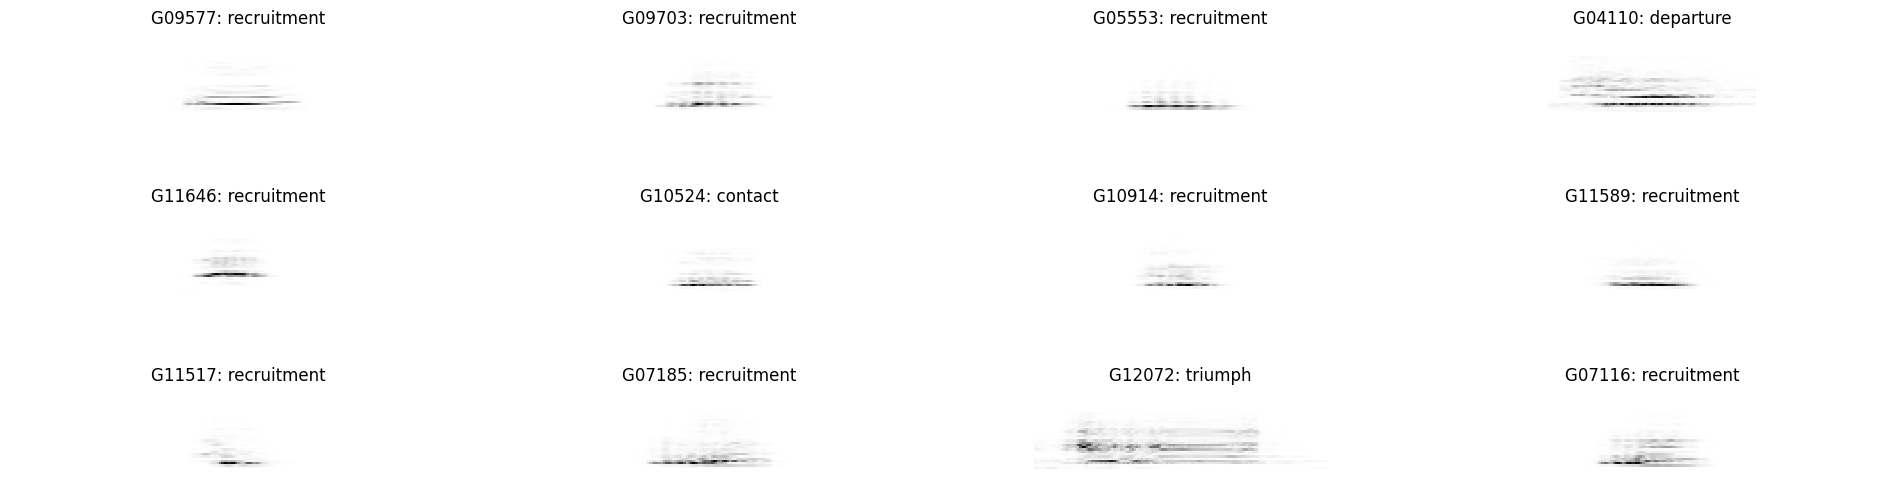

In [48]:
# plot random sample of 8 calls, linearly scaled and padded
sample_calls = merged_df.sample(n=12, random_state=2300)

# plot first 8 calls
#sample_calls = calls_df.iloc[:8]

fig, axes = plt.subplots(3, 4, figsize=(19, 6))

for i, (_, vocalization) in enumerate(sample_calls.iterrows()):
  row = i // 4
  col = i % 4
  axes[row, col].matshow(vocalization["log_padded_spectrogram"], origin="lower", cmap="binary")
  axes[row, col].set_title(f'{vocalization["Clip ID"]}: {vocalization["Call Type"]}', )
  axes[row, col].axis("off") 
    
for i in range(len(sample_calls), 8):
  row = i // 4
  col = i % 4
  axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [49]:
columns_to_drop = [
    "clip_signal_trimmed",
    "clip_signal_bounds",
    "clip_spectrogram_trimmed",
    "same_track",
    "log_target_duration",
    "normalized_log_length",
    "log_duration"
    ]
merged_df = merged_df.drop(columns=columns_to_drop)

In [50]:
merged_df.info()
# TODO zero crossing rate, harmonics to noise ratio

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6639 entries, 0 to 6638
Data columns (total 51 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Track ID                 6639 non-null   object 
 1   Clip ID                  6639 non-null   object 
 2   Goose ID                 6639 non-null   object 
 3   Location                 6639 non-null   object 
 4   Day                      6639 non-null   float64
 5   Month                    6639 non-null   float64
 6   Year                     6639 non-null   float64
 7   Date                     1016 non-null   object 
 8   Time                     6634 non-null   object 
 9   Recorder                 615 non-null    object 
 10  Microphone               6638 non-null   object 
 11  Comment                  996 non-null    object 
 12  Context                  344 non-null    object 
 13  Recorder ID              6639 non-null   object 
 14  Begin Time (s)          

In [51]:
merged_df.to_pickle("features.pkl")